In [ ]:
!pip install diffusers transformers accelerate torch safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 47.8 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0


In [ ]:
import imageio.v3 as iio


In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
model_name = "runwayml/stable-diffusion-v1-5"

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_name,
    torch_dtype=torch.float16
)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
pipe = pipe.to("cuda")

In [ ]:
import torch
from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import export_to_video

# 1. Load the Video Pipeline
pipe = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid-xt",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe.to("cuda")

# 2. Use your existing 'image' variable as the base
# (Ensure the 'image' from your previous cell is resized to 1024x576 or 512x512)
image_input = image.resize((1024, 576))

# 3. Generate Video Frames
generator = torch.manual_seed(42)
frames = pipe(image_input, decode_chunk_size=8, generator=generator).frames[0]

# 4. Export and Save
export_to_video(frames, "generated_video.mp4", fps=7)


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
prompt = "a beautiful 3 layered cake with lot of toppings in butterscotch flavour, full sized cake"

In [ ]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

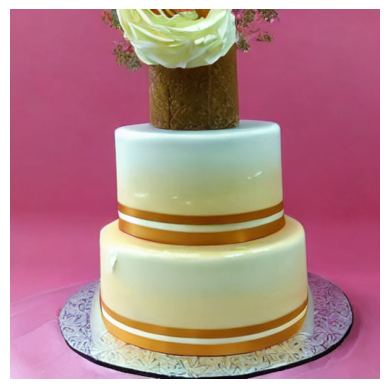

In [ ]:
plt.imshow(image)
plt.axis("off")
plt.show()